In [1]:
import pandas as pd
from pathlib import Path
from math import ceil # arredondar pra cima
#import numpy as np

In [102]:
BASE_DIR = Path("..").resolve()
INFO_PV_FILE = BASE_DIR/'data'/'InfoPV'/'power_station_metadata.csv'
SOLAR_STATION_FILES = BASE_DIR/'data'/'InfoPV'/'solar_station'
generators = pd.read_csv(INFO_PV_FILE)


In [131]:
t_simulation = 24*60*1 #tempo total de simulação em minutos
npts_origin = ceil(t_simulation/15) #quantidade total de passos da simulação
base_irrad = 0.8*1000 #Irradiancia de base em w/m2
step = '1min'

In [156]:
class PVShapeConverter:
    def __init__(self, PV_id, curve_id, npts_origin, generators:pd.DataFrame, start:int=96):
        
        self.name = 'PV-'+str(PV_id)

        #Tratamento de quais curvas vão ser consideradas    
        if curve_id > 51:
            self.curve_id = curve_id % 51
        elif curve_id <= 0:
            print('WARNING: O número de id de entrada do PV foi', curve_id, '\nO número de id de entrada do  PV deve ser igual ou maior que 1, portanto foi atribuído a ele o valor default')
            self.curve_id=1
        else:
            self.curve_id = curve_id
        
        self.npts = npts_origin
        self.curve_id = generators.iloc[curve_id-1, 1]
        self.Pinst_origin = generators.iloc[curve_id-1, 1]
        self.FILE_CSV = self.curve_id + '.csv'
        self.SOLAR_STATION_FILE = SOLAR_STATION_FILES/self.FILE_CSV
        self.solar_station_curves = pd.read_csv(self.SOLAR_STATION_FILE)

        self.datetime = self.solar_station_curves['datetime'].iloc[start:self.npts+start]
        self.datetime = pd.to_datetime(self.datetime)
        self.irrad = (self.solar_station_curves['poa_irradiance_wm2'].iloc[start:self.npts+start])/base_irrad #Pega os valores de irradiância incidente no plano dos paineis.
        for i in range(len(self.irrad)):
            if pd.isna(self.irrad.iloc[i]) or self.irrad.iloc[i] < 0:
                self.irrad.iloc[i] = 0
        self.PV = pd.concat([self.datetime, self.irrad], axis=1)
        #self.PV = self.irrad.to_frame()
        self.PV.set_index('datetime', inplace=True)
    
    def CurveLinearInterpolation(self, nova_taxa):
        """
        Reamostra uma curva de série temporal (Pandas Series) para qualquer intervalo.
        
        Parâmetros:
        - curva: A variável com os dados (Pandas Series com índice de tempo).
        - nova_taxa: String do Pandas para tempo. Ex: '5s' (5 segundos), '1h' (1 hora), '15min'.
        """
        # 1. resample(nova_taxa): Agrupa os dados no novo intervalo
        # 2. mean(): Se for subamostragem (1h), calcula a média dos pontos. 
        #            Se for sobreamostragem (5s), coloca o valor original no ponto exato e NaN (vazio) no resto.
        # 3. interpolate(method='time'): Se houver buracos (sobreamostragem), preenche ligando os pontos proporcionalmente ao tempo.
        
        self.PV = self.PV.resample(nova_taxa).mean().interpolate(method='time')



In [ ]:
PV_generators = [
    {'curve_id':None, 'PV_phases': 3,'PV_voltage_kV': 2.4,'PV_Pinst': 1000,'PV_bus': 97}
]

PV_id = 2
if pd.isna(PV_generators[PV_id-1]['curve_id']):
    PV_generators[PV_id-1]['curve_id'] = PV_id

conversor = PVShapeConverter(
    npts_origin = npts_origin,
    generators = generators, 
    curve_id = PV_generators[PV_id-1]['curve_id'],
    PV_id = PV_id 
)

conversor.curve_id

'PS_002'

In [133]:
conversor.CurveLinearInterpolation(step)
conversor.PV

,poa_irradiance_wm2
datetime,
2024-03-27 00:00:00+00:00,0.0
2024-03-27 00:01:00+00:00,0.0
2024-03-27 00:02:00+00:00,0.0
2024-03-27 00:03:00+00:00,0.0
2024-03-27 00:04:00+00:00,0.0
...,...
2024-03-27 23:41:00+00:00,0.0
2024-03-27 23:42:00+00:00,0.0
2024-03-27 23:43:00+00:00,0.0


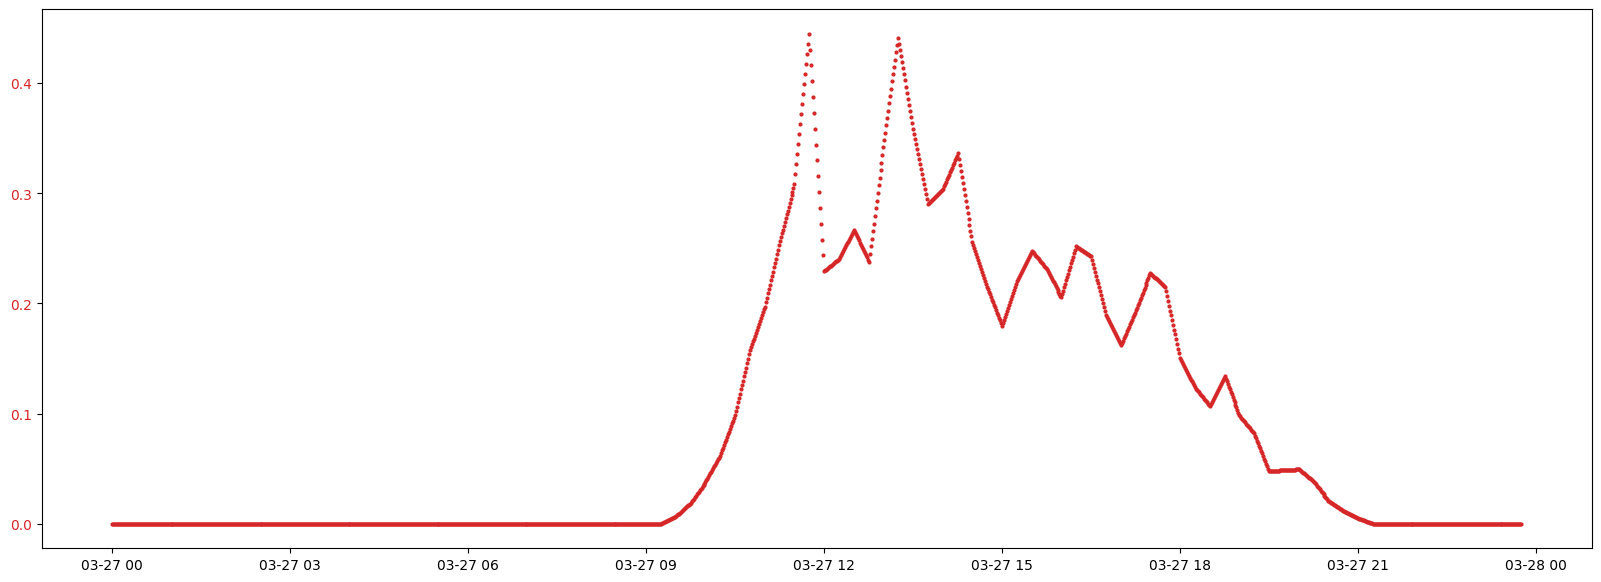

In [134]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(20, 7))

# Adiciona 'o' como marcador (ponto) e remove a linha com linestyle=''
axs.plot(conversor.PV, 
         color='tab:red', 
         marker='o',      # Adiciona ponto em cada dado
         linestyle='',    # Remove a linha (opcional)
         markersize=2)    # Tamanho do ponto (ajuste conforme necessário)

axs.tick_params(axis='y', labelcolor='tab:red')
plt.show()


In [ ]:
# Pega todos os valores da segunda coluna e divide por 1000
valores = (irrad[irrad.columns[1]].values) / 1000

# Formata cada valor com 10 casas decimais, substituindo NaN por 0
valores_formatados = [
    "0.0" if pd.isna(v) or v == 0.0 else f"{v:.16f}"
    for v in valores
]

# Quantidade total de pontos
npts = len(valores_formatados)

# Cria a string no formato DSS
conteudo_dss = f"New LoadShape.MyShapePV1 npts={npts} minterval=1 mult=({', '.join(valores_formatados)})\n"

# Salva como arquivo .dss
nome_arquivo = "src/data/13Bus/LoadShapePV_2.dss"
with open(nome_arquivo, "w") as f:
    f.write(conteudo_dss)

print(f"Processamento concluído! {npts} pontos foram escritos no arquivo.")